In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_squared_error

In [2]:
!pip install xgboost

In [3]:
data=pd.read_csv('/Users/yash/Desktop/GitHub/laptop_price_prediction/Data/Raw/laptop_data (1).csv')

In [4]:
data.shape

(1273, 13)

In [5]:
data.head()

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,No,Yes,226.983005,Intel Core i5,0,128.0,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,No,No,127.677940,Intel Core i5,0,0.0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,No,No,141.211998,Intel Core i5,0,256.0,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,No,Yes,220.534624,Intel Core i7,0,512.0,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,No,Yes,226.983005,Intel Core i5,0,NaN,Intel,Mac


In [6]:
data.tail()

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
1268,Asus,Notebook,4,2.20,10.555257,No,No,100.454670,Intel Core i7,500,0.0,Nvidia,Windows
1269,Lenovo,2 in 1 Convertible,4,1.80,10.433899,Yes,Yes,157.350512,Intel Core i7,0,128.0,Intel,Windows
1270,Lenovo,2 in 1 Convertible,16,1.30,11.288115,Yes,Yes,276.053530,Intel Core i7,0,512.0,Intel,Windows
1271,Lenovo,Notebook,2,1.50,9.409283,No,No,111.935204,Other Intel Processor,0,0.0,Intel,Windows
1272,HP,Notebook,6,2.19,10.614129,No,No,100.454670,Intel Core i7,1000,0.0,AMD,Windows


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1273 non-null   str    
 1   TypeName     1265 non-null   str    
 2   Ram          1273 non-null   int64  
 3   Weight       1273 non-null   float64
 4   Price        1273 non-null   float64
 5   TouchScreen  1273 non-null   str    
 6   Ips          1273 non-null   str    
 7   Ppi          1273 non-null   float64
 8   Cpu_brand    1272 non-null   str    
 9   HDD          1273 non-null   int64  
 10  SSD          1250 non-null   float64
 11  Gpu_brand    1254 non-null   str    
 12  Os           1273 non-null   str    
dtypes: float64(4), int64(2), str(7)
memory usage: 183.4 KB


In [8]:
data.describe()

,Ram,Weight,Price,Ppi,HDD,SSD
count,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1250.000000
mean,8.447761,2.041100,10.828218,146.950812,413.715632,185.993600
std,5.098771,0.669241,0.619565,42.926775,518.054486,186.984892
min,2.000000,0.690000,9.134616,90.583402,0.000000,0.000000
25%,4.000000,1.500000,10.387379,127.335675,0.000000,0.000000
50%,8.000000,2.040000,10.872255,141.211998,0.000000,256.000000
75%,8.000000,2.310000,11.287447,157.350512,1000.000000,256.000000
max,64.000000,4.700000,12.691441,352.465147,2000.000000,1024.000000


In [9]:
x=data.drop('Price',axis=1)
y=data['Price']

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.25)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(954, 12)
(319, 12)
(954,)
(319,)


In [11]:
num_col=x_train.select_dtypes(include=['float64','int64'])

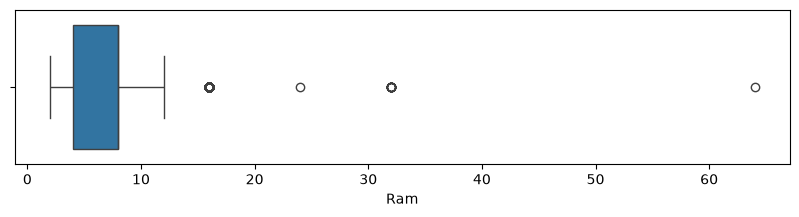

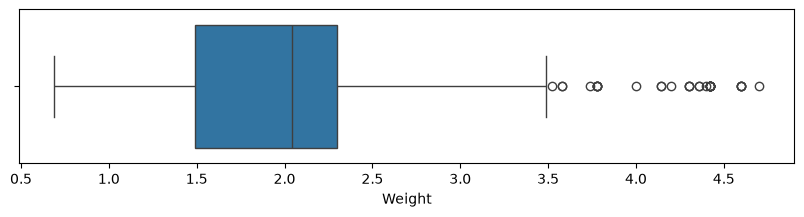

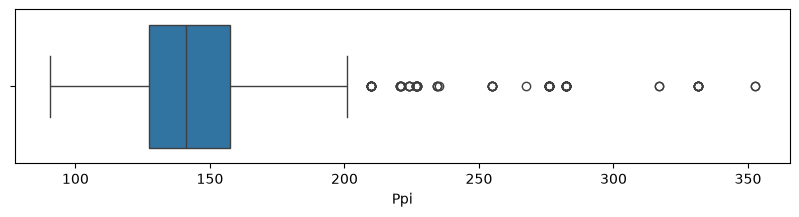

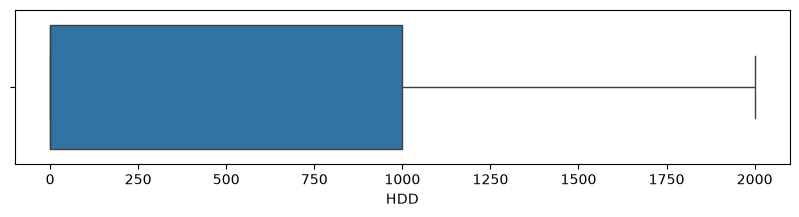

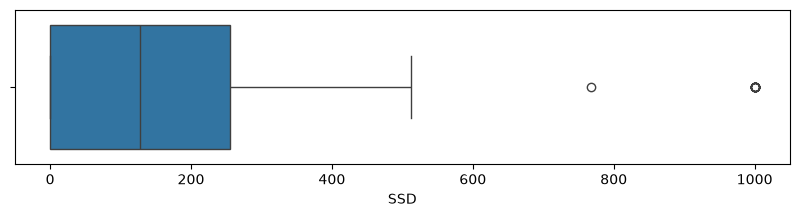

In [12]:
for col in num_col.columns:
    plt.figure(figsize=(10,2))
    sns.boxplot(data=num_col,x=col)

In [13]:
for col in num_col.columns:
    q1=num_col[col].quantile(0.25)
    q3=num_col[col].quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    num_col[col]=num_col[col].clip(lower,upper)

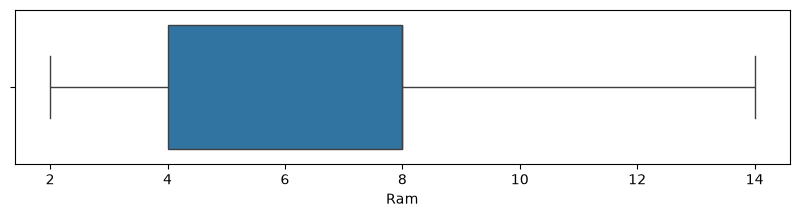

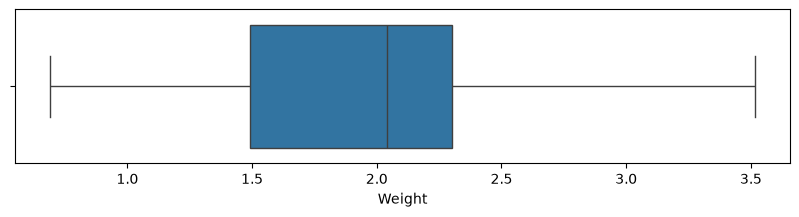

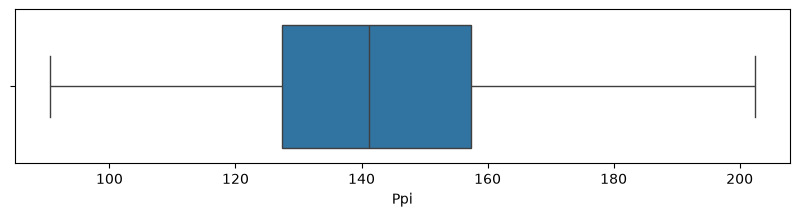

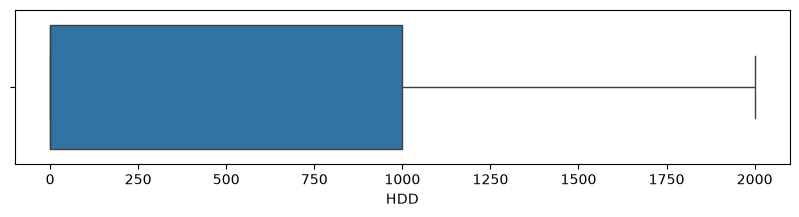

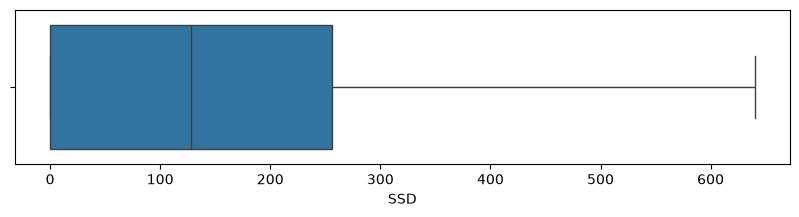

In [14]:
for col in num_col.columns:
    plt.figure(figsize=(10,2))
    sns.boxplot(data=num_col,x=col)

In [15]:
num_pip=Pipeline([('impute',SimpleImputer(strategy='median')),
                  ('scale',StandardScaler())
                  ])

In [16]:
cat_col=x_train.select_dtypes(include=['object'])

/var/folders/78/qfn1w9gd2rd3bwtf0d3ntmr40000gn/T/ipykernel_4992/2589845536.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=x_train.select_dtypes(include=['object'])


In [17]:
for col in cat_col.columns:
    print(col,cat_col[col].unique())

Company <ArrowStringArray>
[   'Lenovo',      'Acer',       'MSI',        'HP',   'Toshiba',      'Dell',
  'Mediacom',      'Asus',     'Chuwi',     'Apple', 'Microsoft',   'Fujitsu',
        'LG',     'Razer',      'Vero',   'Samsung',    'Google',    'Huawei',
    'Xiaomi']
Length: 19, dtype: str
TypeName <ArrowStringArray>
[           'Netbook',           'Notebook',             'Gaming',
          'Ultrabook',        'Workstation', '2 in 1 Convertible',
                  nan]
Length: 7, dtype: str
TouchScreen <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Ips <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Cpu_brand <ArrowStringArray>
['Other Intel Processor',         'Intel Core i5',         'Intel Core i7',
         'Intel Core i3',         'AMD Processor',                     nan]
Length: 6, dtype: str
Gpu_brand <ArrowStringArray>
['Intel', 'AMD', 'Nvidia', nan]
Length: 4, dtype: str
Os <ArrowStringArray>
['Windows', 'Others', 'Mac']
Length: 3, dtype: str


In [18]:
cat_pip=Pipeline([('impute',SimpleImputer(strategy='most_frequent')),
                  ('encode',OneHotEncoder(handle_unknown='ignore'))
                  ])

In [19]:
pre=ColumnTransformer([('num',num_pip,num_col.columns.tolist()),
                       ('cat',cat_pip,cat_col.columns.tolist())
                       ])

In [20]:
model=[LinearRegression(),DecisionTreeRegressor(),RandomForestRegressor(),XGBRegressor()]

In [21]:
performance=[]
for m in model:
    models=Pipeline([('preprocessor',pre),
                     ('model',m)
                     ])
    models.fit(x_train,y_train)
    pred=models.predict(x_test)
    r2=r2_score(y_test,pred)
    rmse=np.sqrt(mean_squared_error(y_test,pred))
    tup=(m,r2,rmse)
    performance.append(tup)

In [22]:
performance=pd.DataFrame(performance,columns=['alg','r2_score','rmse'])

In [23]:
performance

,alg,r2_score,rmse
0,LinearRegression(),0.804937,0.269831
1,DecisionTreeRegressor(),0.797288,0.275071
2,"(DecisionTreeRegressor(max_features=1.0, rando...",0.881072,0.210692
3,"XGBRegressor(base_score=None, booster=None, ca...",0.876093,0.215057


In [24]:
import sys
sys.path.append("..")
from src.Preprocessing import pre_data

In [25]:
data2=pd.read_csv('/Users/yash/Desktop/GitHub/laptop_price_prediction/Data/Raw/laptop_data (1).csv')

In [26]:
data2.head()

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,No,Yes,226.983005,Intel Core i5,0,128.0,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,No,No,127.677940,Intel Core i5,0,0.0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,No,No,141.211998,Intel Core i5,0,256.0,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,No,Yes,220.534624,Intel Core i7,0,512.0,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,No,Yes,226.983005,Intel Core i5,0,NaN,Intel,Mac


In [27]:
x_train,x_test,y_train,y_test,pre=pre_data(data2)

In [28]:
from src.model import train_models

In [29]:
trained_models = train_models(
    pre,
    x_train,
    y_train
)

In [30]:
print(trained_models.keys())

dict_keys(['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'])


In [34]:
from src.evaluation import evaluate_models

In [36]:
results = evaluate_models(
    trained_models,
    x_test,
    y_test
)

In [37]:
results

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.168081,0.217307,0.880519
3,XGBoost,0.167340,0.226510,0.870186
0,Linear Regression,0.213671,0.277458,0.805220
1,Decision Tree,0.209123,0.287136,0.791395


In [38]:
from src.Preprocessing import pre_data
from src.model import train_models
from src.evaluation import evaluate_models

In [39]:
import pandas as pd

data = pd.read_csv("../Data/Raw/laptop_data (1).csv")

In [40]:
x_train, x_test, y_train, y_test, preprocessor = pre_data(data)

In [41]:
trained_models = train_models(
    preprocessor,
    x_train,
    y_train
)

In [42]:
results = evaluate_models(
    trained_models,
    x_test,
    y_test
)

results

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.168081,0.217307,0.880519
3,XGBoost,0.167340,0.226510,0.870186
0,Linear Regression,0.213671,0.277458,0.805220
1,Decision Tree,0.209123,0.287136,0.791395


In [43]:
from src.save_model import save_model

In [44]:
results

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.168081,0.217307,0.880519
3,XGBoost,0.167340,0.226510,0.870186
0,Linear Regression,0.213671,0.277458,0.805220
1,Decision Tree,0.209123,0.287136,0.791395


In [45]:
best_model_name = results.iloc[0]["Model"]

print(best_model_name)

Random Forest


In [46]:
best_model = trained_models[best_model_name]